# 04 — Mạng học khoảng cách: hồi quy log, L1, rò rỉ dữ liệu, chọn epoch, ensemble

Hai công thức ở notebook 01 mỗi cái chỉ dùng một manh mối (chiều cao khung, hoặc cạnh dưới) và
một giả định cứng. Mạng ở đây đọc **cùng khung bao đó** nhưng tự học cách kết hợp các manh mối
từ hàng chục nghìn ví dụ có LiDAR. Nó thắng cả hai công thức: 7,9% so với 18,1% và 31,5% trên phép
chia cố định mà notebook này dùng; kiểm định chéo 3 phần trên cả 21 chuỗi (README) cho 8,1% so với
12,6% và 24,0%.
Notebook này đi qua từng quyết định thiết kế và kiểm chứng từng cái bằng thí nghiệm nhỏ trên
dữ liệu thật; mọi thứ chạy trên CPU.

| Mục | Câu hỏi |
|---|---|
| 1. Dữ liệu huấn luyện | Học từ đâu, bao nhiêu ví dụ? |
| 2. Đặc trưng | Mạng nhìn thấy những số nào? |
| 3. Dự đoán log Z với L1 | Vì sao không dự đoán thẳng Z với bình phương sai số? |
| 4. Chuẩn hoá đầu vào | Vì sao trừ trung bình, chia độ lệch chuẩn? |
| 5. Rò rỉ dữ liệu | Chia theo khung hình thì sai ở đâu? |
| 6. Chọn số epoch | Leave-one-sequence-out |
| 7. Ensemble nhiều hạt giống | Vì sao một mạng chưa đủ tin cậy? |
| 8. Kết quả và một sai lầm của dự án | |

In [1]:
import json
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

from monodist import kitti, match, mlp, geometry, metrics, evaluate as E
from monodist.detect import merge

torch.set_num_threads(2)
ROOT = Path("../data/kitti_tracking")
plt.rcParams.update({"figure.figsize": (9, 3.2), "figure.dpi": 110})

CONFIG = "coco_1280"
res = json.loads(Path(f"../results/eval/{CONFIG}.json").read_text())
det, sizes = merge(f"../results/det/{CONFIG}")
cam = E.camera(ROOT, kitti.SEQUENCES, sizes)
gt = match.ground_truth(ROOT, kitti.SEQUENCES)
status, gt_idx = match.evaluate(det, gt)
conf = [res["conf"][c] for c in kitti.CLASSES]
pairs = match.matched_pairs(det, gt, status, gt_idx, match.per_detection_conf(det, conf))
pairs = {k: v[pairs["z"] >= E.MIN_Z] for k, v in pairs.items()}
train, val, test = (E.subset(pairs, kitti.SPLIT[s]) for s in ("train", "val", "test"))
print({s: len(p["z"]) for s, p in (("train", train), ("val", val), ("test", test))}, "matched detections (object-frames)")

{'train': 17357, 'val': 5708, 'test': 5940} matched detections (object-frames)


## 1. Dữ liệu huấn luyện

Mỗi ví dụ là **một khung bao do bộ nhận diện sinh ra** trên một chuỗi train, đã được ghép với
một vật có nhãn (IoU $\ge 0{,}5$, notebook 02), kèm khoảng cách thật $z$ của vật đó.

Học trên khung của **bộ nhận diện**, không phải khung của nhãn, vì lúc dùng thật mạng chỉ nhận
được khung của bộ nhận diện. Khung nhãn thì luôn khít; khung dự đoán có sai lệch riêng (thấp hơn,
lệch mép, bị cắt khác). Học trên khung nhãn rồi chạy trên khung dự đoán là tạo ra **lệch phân
phối** giữa lúc học và lúc dùng.

**Ký hiệu mới**
- **lệch phân phối** (distribution shift): dữ liệu lúc dùng khác dữ liệu lúc học về tính chất thống kê

## 2. Đặc trưng

Bảy số cho mỗi khung, mọi đại lượng pixel đều **chia cho $f$** để thành góc (notebook 00, mục 2):

| Đặc trưng | Manh mối |
|---|---|
| $h/f$, $w/f$ | kích thước góc của khung: manh mối của công thức kích thước |
| $(v_2 - c_y)/f$ | góc từ chân trời xuống cạnh dưới: manh mối của công thức mặt phẳng sàn |
| $(v_1 - c_y)/f$, $(u_{giữa} - c_x)/f$ | vị trí khung trong trường nhìn |
| pedestrian | 0 cho ô tô, 1 cho người |
| cut | 1 nếu khung chạm mép ảnh (vật bị cắt, chiều cao khung không đáng tin) |

Chia cho $f$ làm cho cùng một vật chụp bằng camera $f = 707$ hay $f = 722$ cho **cùng đặc trưng**,
nên mạng học trên chuỗi này dùng được cho chuỗi khác (có một bài kiểm tra đơn vị cho tính chất
này trong `tests/test_geometry.py`).

In [2]:
X_train = E.feats(train, cam)
np.set_printoptions(precision=4, suppress=True)
print("features:", geometry.FEATURES)
print(X_train[:3])
print("z of these rows:", np.round(train["z"][:3], 2))

features: ('h/f', 'w/f', '(v2-cy)/f', '(v1-cy)/f', '(u-cx)/f', 'pedestrian', 'cut')
[[ 0.2525  0.6196  0.2734  0.0209  0.5535  0.      0.    ]
 [ 0.069   0.1083  0.0994  0.0304 -0.2594  0.      0.    ]
 [ 0.1234  0.1703  0.1368  0.0133  0.2367  0.      0.    ]]
z of these rows: [ 6.35 23.72 13.17]


## 3. Dự đoán $\log Z$ với hàm mất mát L1

**Vì sao dự đoán $\log Z$.** Sai số tự nhiên của bài toán là sai số **tương đối** (notebook 01:
$dZ/Z = dH/H - dh/h$). Nếu dự đoán thẳng $Z$ với sai số tuyệt đối, sai 1 m ở 5 m và sai 1 m ở 60
m bị phạt như nhau, nên mạng sẽ dồn sức vào vật xa. Với logarit:

$$|\log \hat Z - \log Z| = \left|\log\frac{\hat Z}{Z}\right| \approx \left|\frac{\hat Z}{Z} - 1\right| = \text{AbsRel},$$

(xấp xỉ dùng $\log(1+\epsilon) \approx \epsilon$ khi $\epsilon$ nhỏ). Sai số trên $\log Z$ chính là
sai số tương đối. Thêm nữa, $\log Z = \log f + \log H - \log h$ (notebook 01): theo $\log h$, quan hệ
gần như **tuyến tính**, nên một mạng nhỏ học dễ.

**Vì sao L1 chứ không bình phương (L2).**

$$\mathcal L_1 = \frac1n\sum_i |\hat y_i - y_i|, \qquad \mathcal L_2 = \frac1n\sum_i (\hat y_i - y_i)^2.$$

Nếu mạng chỉ được đoán **một hằng số** $c$ cho mọi ví dụ, thì $\mathcal L_2$ nhỏ nhất khi $c$ là
**trung bình**, còn $\mathcal L_1$ nhỏ nhất khi $c$ là **trung vị**. Trung vị ít bị kéo bởi vài
ví dụ cực đoan (ví dụ một khung bị ghép nhầm với vật ở xa gấp đôi). Kiểm chứng bằng số:

**Ký hiệu mới**
- $y_i = \log z_i$: mục tiêu của ví dụ $i$ · $\hat y_i$: dự đoán · $\mathcal L_1, \mathcal L_2$: hàm mất mát L1 và L2

In [3]:
y = np.log(train["z"])
cs = np.linspace(y.min(), y.max(), 2001)
l1 = [np.mean(np.abs(y - c)) for c in cs]
l2 = [np.mean((y - c) ** 2) for c in cs]
print(f"best constant under L1: {cs[np.argmin(l1)]:.3f}  | median of y: {np.median(y):.3f}")
print(f"best constant under L2: {cs[np.argmin(l2)]:.3f}  | mean of y:   {np.mean(y):.3f}")

best constant under L1: 2.983  | median of y: 2.983
best constant under L2: 2.917  | mean of y:   2.916


## 4. Chuẩn hoá đầu vào

Bảy đặc trưng có thang rất khác nhau: $h/f$ cỡ 0,01–0,5, còn "pedestrian" là 0 hoặc 1. Trước
lớp đầu tiên, mạng trừ trung bình và chia độ lệch chuẩn của **tập train** cho từng đặc trưng:

$$\tilde x_j = \frac{x_j - \mu_j}{\sigma_j}.$$

Mọi đặc trưng khi đó có trung bình 0, độ lệch chuẩn 1, nên AdamW không phải bù thang cho từng
chiều. $\mu, \sigma$ được lưu *trong* mạng (`register_buffer`), nên lúc dự đoán dùng đúng giá trị
của tập train, không tính lại trên dữ liệu mới.

**Ký hiệu mới**
- $\mu_j, \sigma_j$: trung bình và độ lệch chuẩn của đặc trưng $j$ trên tập train

## 5. Rò rỉ dữ liệu: chia theo khung hình thì sai ở đâu

Để chọn số epoch, cần một phần dữ liệu **không dùng để học** để đo sai số. Cách ngây thơ: rút
ngẫu nhiên 20% số dòng. Nhưng KITTI là video 10 khung/giây: một chiếc xe xuất hiện ở hàng chục
khung liền nhau với khung bao gần như y hệt. Chia ngẫu nhiên theo dòng thì gần như mọi dòng
"kiểm tra" đều có một dòng gần như sinh đôi trong phần học. Đó là **rò rỉ dữ liệu**: phần kiểm
tra không còn là dữ liệu mới, nên sai số đo được **đẹp giả tạo**.

Cách đúng: chia theo **nhóm** (ở đây là chuỗi video), để mọi khung của một chiếc xe nằm cùng một
phía. So hai cách trên cùng dữ liệu train, cùng mạng, cùng 40 epoch:

**Ký hiệu mới**
- **rò rỉ dữ liệu** (data leakage): thông tin của phần kiểm tra lọt vào phần học

In [4]:
def absrel_of(model, X, z):
    return float(np.mean(np.abs(mlp.predict(model, X) - z) / z))

logz = np.log(train["z"])
rng = np.random.default_rng(0)
rand = rng.random(len(logz)) < 0.2                           # 20 % of the rows, at random
held_seq = np.isin(train["seq"], ["0013", "0019"])            # two whole sequences (~20 % of the rows)
X_test = E.feats(test, cam)
for name, held in (("random 20% of rows", rand), ("two whole sequences", held_seq)):
    model, _ = mlp._fit(X_train[~held], logz[~held], epochs=40, seed=0)
    print(f"{name:20s}: held-out AbsRel {absrel_of(model, X_train[held], train['z'][held]):.3f} "
          f"| true test-set AbsRel {absrel_of(model, X_test, test['z']):.3f}")

random 20% of rows  : held-out AbsRel 0.060 | true test-set AbsRel 0.088


two whole sequences : held-out AbsRel 0.089 | true test-set AbsRel 0.110


Chia ngẫu nhiên theo dòng báo sai số giữ-lại 6,0% trong khi chính mạng đó sai 8,8% trên tập test:
nó hứa hẹn tốt hơn thực tế gần một phần ba. Chia theo chuỗi cho con số sát thực tế hơn. Cũng vì lý do này, cả dự án chia
train/val/test **theo chuỗi**, và khoảng tin cậy ở notebook 05 lấy mẫu lại **theo vật** chứ không
theo khung hình.

## 6. Chọn số epoch: leave-one-sequence-out

Huấn luyện quá ít thì mạng chưa học xong; quá nhiều thì nó bắt đầu học thuộc những chuỗi train.
Cách chọn của dự án (`mlp.train`):

1. Với mỗi chuỗi trong 8 chuỗi train: học trên 7 chuỗi còn lại, sau mỗi epoch đo L1 trên chuỗi
   bị để ra.
2. Lấy trung bình 8 đường cong; epoch có trung bình thấp nhất là số epoch được chọn.
3. Học lại trên **cả 8 chuỗi** với đúng số epoch đó.

Đây là **kiểm định chéo theo nhóm** (leave-one-group-out cross-validation). Đường cong trung
bình của lần chạy thật:

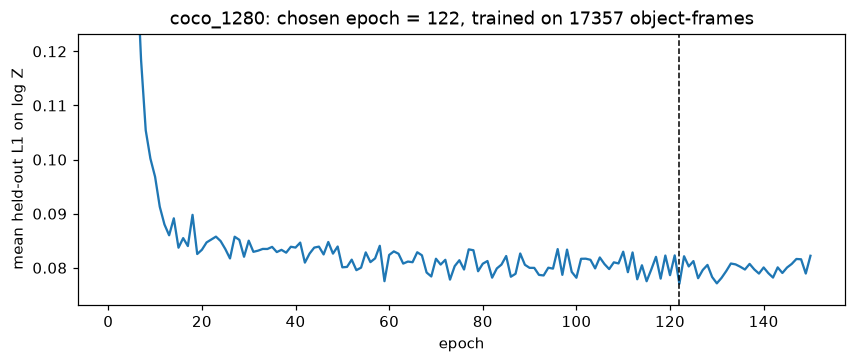

In [5]:
curve = np.array(res["mlp"]["heldout_l1_log"])
plt.plot(np.arange(1, len(curve) + 1), curve)
plt.axvline(res["mlp"]["epochs"], color="k", ls="--", lw=1)
plt.xlabel("epoch"); plt.ylabel("mean held-out L1 on log Z"); plt.ylim(curve.min() * 0.95, curve.min() * 1.6)
plt.title(f"{CONFIG}: chosen epoch = {res['mlp']['epochs']}, trained on {res['mlp']['n_train']} object-frames")
plt.show()

Đường cong giảm nhanh rồi gần như phẳng: chọn epoch nào trong vùng phẳng thì kết quả cũng gần
nhau. L1 trung bình trên $\log Z$ khoảng 0,08 tương ứng sai số tương đối trung bình khoảng 8% trên
các chuỗi chưa thấy (xấp xỉ ở mục 3).

## 7. Ensemble nhiều hạt giống

**Hạt giống** (seed) quyết định trọng số khởi tạo và thứ tự xáo dữ liệu. Hai mạng giống hệt nhau
về thiết kế nhưng khác hạt giống cho kết quả hơi khác nhau. Trong dự án, hai cấu hình cho khung
gần như trùng nhau (PyTorch fp32 và fp16) từng cho sai số MLP lệch nhau 0,9 điểm, bằng cỡ những
chênh lệch đang cần đo. Đo trực tiếp độ dao động đó:

In [6]:
E_best = res["mlp"]["epochs"]
single = []
models = []
for seed in range(5):
    model, _ = mlp._fit(X_train, logz, epochs=E_best, seed=seed)
    models.append(model)
    single.append(absrel_of(model, X_test, test["z"]))
print("test AbsRel of five single seeds:", np.round(single, 4), f"-> spread {max(single) - min(single):.4f}")
print(f"ensemble of the five (mean of log Z): {absrel_of(models, X_test, test['z']):.4f}")
print(f"project result (same recipe):         {res['distance']['mlp']['all']['absrel_mean'][0]:.4f}")

test AbsRel of five single seeds: [0.0802 0.0852 0.0791 0.089  0.0787] -> spread 0.0102
ensemble of the five (mean of log Z): 0.0786
project result (same recipe):         0.0786


Mỗi hạt giống lệch nhau cỡ nửa điểm đến một điểm phần trăm. **Ensemble** lấy trung bình dự đoán
$\log Z$ của năm mạng (tức trung bình nhân của $\hat Z$), triệt phần dao động ngẫu nhiên đó. Chi
phí thêm khoảng 0,1 ms mỗi khung hình (notebook 06).

**Ký hiệu mới**
- **ensemble**: kết hợp dự đoán của nhiều mô hình · **trung bình nhân**: $\big(\prod_k \hat Z_k\big)^{1/K}$, bằng $\exp$ của trung bình $\log \hat Z_k$

## 8. Kết quả, và một sai lầm của dự án

In [7]:
d = res["distance"]
for m_name, label in (("size", "known size"), ("ground", "ground plane"), ("mlp", "MLP")):
    cells = [f"{d[m_name][g]['absrel_mean'][0]:6.1%}" for g in ("all", "Car 0-10 m", "Car 10-20 m", "Car 20-40 m", "Car >40 m", "Pedestrian")]
    print(f"{label:13s} all {cells[0]} | car 0-10 {cells[1]} 10-20 {cells[2]} 20-40 {cells[3]} >40 {cells[4]} | ped {cells[5]}")

known size    all  18.1% | car 0-10  73.7% 10-20   9.5% 20-40   6.7% >40   7.8% | ped   8.5%
ground plane  all  31.5% | car 0-10  44.8% 10-20  18.9% 20-40  28.8% >40  35.1% | ped  31.8%
MLP           all   7.9% | car 0-10  17.6% 10-20   5.4% 20-40   6.0% >40   6.9% | ped   6.1%


- Mạng thắng rõ nhất ở **ô tô gần** (17,6% so với 73,7%): 64% ô tô ở 2–10 m bị mép ảnh cắt, nên
  chiều cao khung không còn là chiều cao xe. Đặc trưng "cut" cộng với vị trí khung cho mạng biết
  khi nào phải dựa vào cạnh dưới thay vì chiều cao.
- Ở 10–20 m nó giảm một nửa sai số của công thức kích thước (5,4% so với 9,5%): nó học được phần
  bù cho hiệu ứng chiều dài xe (notebook 01, mục 3).

**Sai lầm đã mắc.** Bản đầu tiên của dự án huấn luyện mạng này trên **tập val** thay vì tập train,
với lý do tránh khung "quá khít" của bộ nhận diện fine-tune trên ảnh nó đã học (notebook 03, mục 6).
Nhưng người đi bộ trong tập val gần như đến từ một chuỗi duy nhất:

In [8]:
for s in kitti.SPLIT["val"]:
    print(s, "pedestrian object-frames:", int(((val["seq"] == s) & (val["cls"] == 1)).sum()))
share = ((val["seq"] == "0016") & (val["cls"] == 1)).sum() / (val["cls"] == 1).sum()
print(f"share from sequence 0016: {share:.0%}")

0003 pedestrian object-frames: 0
0004 pedestrian object-frames: 36
0006 pedestrian object-frames: 0
0011 pedestrian object-frames: 89
0016 pedestrian object-frames: 1380
share from sequence 0016: 92%


Một chuỗi nghĩa là một con phố, một nhóm người, một kiểu ánh sáng. Mạng học trên đó thua cả công
thức kích thước với người đi bộ (22,9% so với 8,7%). Chuyển sang tập train (8 chuỗi, nhiều hơn
khoảng ba lần) sửa được. Bài học: **đa dạng của dữ liệu học quan trọng hơn một lo ngại nhỏ về độ
khít của khung**, và lo ngại đó được đo trực tiếp (1,5 điểm IoU) thay vì đoán.

## Tóm tắt

- Mạng học trên **khung của bộ nhận diện** trên tập train, với 7 đặc trưng đều chia cho $f$.
- Dự đoán $\log Z$ vì sai số của bài toán là tương đối; L1 vì nó cho trung vị, bền với ví dụ cực đoan.
- Chia theo dòng rò rỉ thông tin giữa các khung liền nhau; phải chia theo chuỗi.
- Chọn epoch bằng leave-one-sequence-out; lấy trung bình 5 hạt giống để triệt dao động ngẫu nhiên.
- Kết quả 7,9%, thắng rõ nhất ở ô tô gần bị cắt mép và ở dải 10–20 m.